In [1]:
import os
import platform
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
# 采用pytorch_lighting框架
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping


In [2]:
os.getcwd()

'/home/czy/KT/BRIKT_mine'

In [3]:
seed = 42
np.random.seed(seed) # 设置numpy随机数种子
torch.manual_seed(seed) # 为CPU中设置种子，生成随机数
torch.cuda.manual_seed_all(seed) # 为所有GPU设置种子，生成随机数
pl.seed_everything(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Global seed set to 42


### hyperparameter tuning

In [4]:
SEQ_LEN = 200
# SEQ_LEN = 65
# BATCH_SIZE = 256
BATCH_SIZE = 64
EMBED_DIM = 128
DROP_OUT = 0.8
NUM_WORKERS = 0 if platform.system() == 'Windows' else 4
# N_GCN_LAYERS = 0 # 
N_GCN_LAYERS = 3
print("os:{}, num-workers:{}".format(platform.system(), NUM_WORKERS))

os:Linux, num-workers:4


###  assist09 dataset

In [5]:
# train : validation = 80% : 20%
df_train = pd.read_csv('dataset/assist09/train.csv', low_memory=False, encoding="ISO-8859-1")
df_val = pd.read_csv('dataset/assist09/test.csv', low_memory=False, encoding="ISO-8859-1")
df_train.head()

,user_id,q_idx,s_idx,q_type,q_diff,ms_first_response,attempt_count,correct
0,96245.0,11.0,0.0,0.0,0.625000,0.010081,0.000523,0.0
1,96245.0,24.0,0.0,0.0,0.738095,0.010259,0.000523,0.0
2,96245.0,31.0,0.0,0.0,0.613636,0.010298,0.000523,0.0
3,96245.0,48.0,0.0,0.0,0.787879,0.010179,0.000523,0.0
4,96245.0,56.0,0.0,0.0,0.736842,0.010344,0.000523,0.0


In [6]:
# train : validation = 70% : 30%
# df_train = pd.read_csv('dataset/assist09/train_7.csv', low_memory=False, encoding="ISO-8859-1")
# df_val = pd.read_csv('dataset/assist09/test_3.csv', low_memory=False, encoding="ISO-8859-1")
# df_train.head()

In [7]:
# # train : validation = 60% : 40%
# df_train = pd.read_csv('dataset/assist09/train_6.csv', low_memory=False, encoding="ISO-8859-1")
# df_val = pd.read_csv('dataset/assist09/test_4.csv', low_memory=False, encoding="ISO-8859-1")
# df_train.head()

In [8]:
key = 'problem_id'

key_q = 'q_idx'
key_s = 's_idx'
key_qt = 'q_type'
key_qd = 'q_diff'
key_ms_first_response = 'ms_first_response'
key_attempts = 'attempt_count'

In [9]:
# 我们需要将数据进行预处理，每个学生的学习记录利用group by合并为序列。
def generate_group_by_df(df):
    group = df[['user_id', key_q, key_s, key_qt, key_qd, key_ms_first_response, key_attempts, 'correct']].groupby(['user_id']).apply(lambda r: (
            r[key_q].values,
            r[key_s].values,
            r[key_qt].values,
            r[key_qd].values,
            r[key_ms_first_response].values,
            r[key_attempts].values,
            r['correct'].values
            ))
    return group

In [10]:
train = generate_group_by_df(df_train) 
val = generate_group_by_df(df_val)
train.head()

user_id
14.0       ([132.0, 133.0, 134.0, 135.0, 136.0, 137.0, 13...
21825.0    ([1364.0, 1365.0, 1366.0, 1367.0, 1368.0, 1369...
51950.0    ([14102.0, 14103.0, 14104.0, 14105.0, 15142.0,...
52613.0    ([572.0, 10133.0, 11736.0, 16060.0, 16061.0, 1...
53167.0    ([925.0, 926.0, 927.0, 928.0, 929.0, 1371.0, 1...
dtype: object

In [11]:
len(train)

3320

In [12]:
train.iloc[0]

(array([ 132.,  133.,  134.,  135.,  136.,  137.,  138.,  139.,  140.,
         141.,  142.,  143., 2208., 2209., 2210., 2211., 2377., 2378.,
        2379.]),
 array([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  9.,
         9.,  9.,  9., 10., 10., 10.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]),
 array([0.41666667, 0.37931034, 0.34782609, 0.35135135, 0.25806452,
        0.43478261, 0.41666667, 0.52631579, 0.83333333, 0.77777778,
        0.625     , 0.66666667, 0.58333333, 0.22222222, 0.45454545,
        0.375     , 0.6       , 0.72727273, 0.83333333]),
 array([0.01022905, 0.01026264, 0.01008195, 0.01011871, 0.01005015,
        0.01001677, 0.01017739, 0.01062496, 0.0106761 , 0.01089205,
        0.01028095, 0.01024029, 0.01002845, 0.00996003, 0.01006   ,
        0.00994574, 0.0100567 , 0.01004937, 0.01005413]),
 array([0.00026151, 0.00026151, 0.00026151, 0.00026151, 0.00026151,
        0.00026151, 0.00026151, 0.        

In [13]:
train.iloc[0][0], len(train.iloc[0][0])

(array([ 132.,  133.,  134.,  135.,  136.,  137.,  138.,  139.,  140.,
         141.,  142.,  143., 2208., 2209., 2210., 2211., 2377., 2378.,
        2379.]),
 19)

In [14]:
len_list = [len(train.iloc[i][0]) for i in range(len(train))]
print("seq_len mean:{}, max:{}, min:{}".format(np.mean(len_list), np.max(len_list), np.min(len_list)))

seq_len mean:65.99367469879518, max:1040, min:1


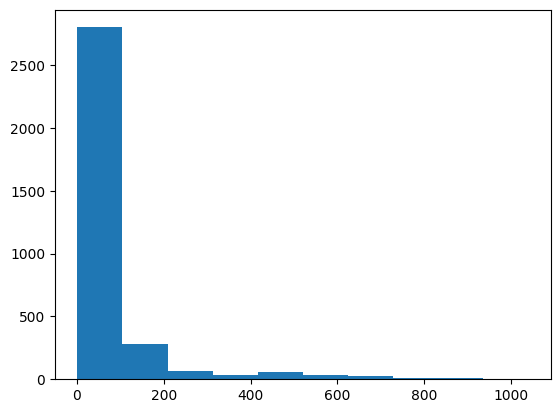

In [15]:
import matplotlib.pyplot as plt
plt.hist(len_list)
plt.show()

In [16]:
len_list = [len(val.iloc[i][0]) for i in range(len(val))]
print("seq_len mean:{}, max:{}, min:{}".format(np.mean(len_list), np.max(len_list), np.min(len_list)))

seq_len mean:66.77617328519855, max:927, min:1


In [17]:
# len(train) # 3320

In [18]:
# len(val) # 831

In [19]:
with open('dataset/assist09/pro_id_dict.txt', 'r') as f:
    pro_id_dict = eval(f.read())
N_QUESTION = len(pro_id_dict)

with open('dataset/assist09/skill_id_dict.txt', 'r') as f:
    skill_id_dict = eval(f.read())
N_SKILL = len(skill_id_dict)

with open('dataset/assist09/pro_type_dict.txt', 'r') as f:
    pro_type_dict = eval(f.read())
N_QUESTION_TYPE = len(pro_type_dict)

# num of question:16891, num of skill:101, n_question_type:5
print("num of question:{}, num of skill:{}, n_question_type:{}".format(N_QUESTION, N_SKILL, N_QUESTION_TYPE))

num of question:16891, num of skill:101, n_question_type:5


In [20]:
# 'q_idx', 's_idx', 'q_type', 'q_diff', 'ms_first_response', 'attempt_count'
N_QUERY_FEATURES = len(train.iloc[0])-1
print("N_QUERY_FEATURES:{}".format(N_QUERY_FEATURES)) # N_QUERY_FEATURES:6

N_QUERY_FEATURES:6


In [21]:

from dataloader.assist09 import Assist09Dataset
train_dataset = Assist09Dataset(train, N_QUESTION, SEQ_LEN)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

val_dataset = Assist09Dataset(val, N_QUESTION, SEQ_LEN)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [22]:
# print(len(train_dataset), len(val_dataset)) # 总共4151个user, 3320 + 831 = 4151
# print(train_dataset[0][0].shape) # 序列长度为

### load birepart data

In [23]:
from utils.bipartited_data import load_bipartitedata
from utils.bipartited_data import load_bipartitedata
df_edge = pd.read_table(('dataset/assist09/edge_list.dat'), sep='\t')
gcn_data, q_rev_dict, s_rev_dict, q_dict, s_dict = load_bipartitedata(df_edge)
# gcn_data: BipartiteData(edge_index_q2s=[2, 16892], edge_index_s2q=[2, 16892], num_q=16892, num_s=102)
gcn_data = gcn_data.to("cuda") 

In [24]:
# from model.brikt26 import MYModule
# model = MYModule(
#     n_question=N_QUESTION,
#     n_skill=N_SKILL,
#     n_qtype=N_QUESTION_TYPE,
#     max_seq=SEQ_LEN,
#     embed_dim=EMBED_DIM,
#     n_query_features=N_QUERY_FEATURES,
#     n_gcn_layers=N_GCN_LAYERS,
#     gcn_data=gcn_data,
#     dropout=DROP_OUT,
#     new_att=True
# )

In [25]:
from model.brikt26 import MYModule
model = MYModule(
    n_question=N_QUESTION,
    n_skill=N_SKILL,
    n_qtype=N_QUESTION_TYPE,
    max_seq=SEQ_LEN,
    embed_dim=EMBED_DIM,
    n_query_features=N_QUERY_FEATURES,
    n_gcn_layers=N_GCN_LAYERS,
    gcn_data=gcn_data,
    dropout=DROP_OUT,
    new_att=True
)
print(model)

16891 101 5 200 128 6 BipartiteData(edge_index_q2s=[2, 16892], edge_index_s2q=[2, 16892], num_q=16892, num_s=102)
MYModule(
  (loss): BCEWithLogitsLoss()
  (model): MYMODEL(
    (embedding): Embedding(33783, 128)
    (qt_embedding): Embedding(5, 128)
    (diff_embedding): Linear(in_features=1, out_features=128, bias=True)
    (ms_first_response_embedding): Linear(in_features=1, out_features=128, bias=True)
    (attempt_count_embedding): Linear(in_features=1, out_features=128, bias=True)
    (combine_q_embedding_q): Linear(in_features=512, out_features=128, bias=True)
    (q_feature_layer_norm_q): LayerNorm((199, 128), eps=1e-05, elementwise_affine=True)
    (combine_q_embedding_x): Linear(in_features=384, out_features=128, bias=True)
    (q_feature_layer_norm_x): LayerNorm((199, 128), eps=1e-05, elementwise_affine=True)
    (gcn): LightGCNStack(
      (convs): ModuleList(
        (0): LightGCN()
        (1): LightGCN()
        (2): LightGCN()
      )
      (embed_q): Embedding(16892, 1

In [26]:
# from model.brikt26_no_sideinformation import MYModule
# model = MYModule(
#     n_question=N_QUESTION,
#     n_skill=N_SKILL,
#     n_qtype=N_QUESTION_TYPE,
#     max_seq=SEQ_LEN,
#     embed_dim=EMBED_DIM,
#     n_query_features=2,
#     n_gcn_layers=N_GCN_LAYERS,
#     gcn_data=gcn_data,
#     dropout=DROP_OUT,
#     new_att=True
# )
# print(model)

In [27]:
# 以AUC为评价指标，保存最好的模型
checkpoint_callback = pl.callbacks.ModelCheckpoint(save_top_k=1, verbose=True, monitor='v_auc', mode='max')

In [28]:
patience = 6 if N_QUERY_FEATURES == 6 else 3
print("patience:{}".format(patience))

patience:6


In [29]:
trainer = pl.Trainer(
    gpus=1, 
    max_epochs=200, 
    auto_lr_find=True, 
    callbacks=[checkpoint_callback, EarlyStopping(monitor="v_auc", mode="max", patience=6)]
)

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [30]:
trainer.fit(model=model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params
--------------------------------------------
0 | loss  | BCEWithLogitsLoss | 0     
1 | model | MYMODEL           | 6.8 M 
--------------------------------------------
6.8 M     Trainable params
0         Non-trainable params
6.8 M     Total params
27.270    Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Epoch 0, global step 52: 'v_auc' reached 0.75540 (best 0.75540), saving model to '/home/czy/KT/BRIKT_mine/lightning_logs/version_65/checkpoints/epoch=0-step=52.ckpt' as top 1


...

Epoch 13, global step 728: 'v_auc' was not in top 1


Validation: 0it [00:00, ?it/s]

Epoch 14, global step 780: 'v_auc' was not in top 1


Validation: 0it [00:00, ?it/s]

Epoch 15, global step 832: 'v_auc' was not in top 1


In [31]:
os.getcwd()

'/home/czy/KT/BRIKT_mine'

In [32]:
version = 'version_64'
checkpoint = 'epoch=9-step=520.ckpt'
checkpoint_path = os.path.join(os.getcwd(), 'lightning_logs', version, 'checkpoints', checkpoint)

cp = model.load_from_checkpoint(
    checkpoint_path=checkpoint_path, 
    n_question=N_QUESTION,
    n_skill=N_SKILL,
    n_qtype=N_QUESTION_TYPE,
    max_seq=SEQ_LEN,
    embed_dim=EMBED_DIM,
    n_query_features=N_QUERY_FEATURES,
    n_gcn_layers=N_GCN_LAYERS,
    gcn_data=gcn_data,
    dropout=DROP_OUT,
    new_att=True)
cp.cuda()
cp.eval()

16891 101 5 200 128 6 BipartiteData(edge_index_q2s=[2, 16892], edge_index_s2q=[2, 16892], num_q=16892, num_s=102)


MYModule(
  (loss): BCEWithLogitsLoss()
  (model): MYMODEL(
    (embedding): Embedding(33783, 128)
    (qt_embedding): Embedding(5, 128)
    (diff_embedding): Linear(in_features=1, out_features=128, bias=True)
    (ms_first_response_embedding): Linear(in_features=1, out_features=128, bias=True)
    (attempt_count_embedding): Linear(in_features=1, out_features=128, bias=True)
    (combine_q_embedding_q): Linear(in_features=512, out_features=128, bias=True)
    (q_feature_layer_norm_q): LayerNorm((199, 128), eps=1e-05, elementwise_affine=True)
    (combine_q_embedding_x): Linear(in_features=384, out_features=128, bias=True)
    (q_feature_layer_norm_x): LayerNorm((199, 128), eps=1e-05, elementwise_affine=True)
    (gcn): LightGCNStack(
      (convs): ModuleList(
        (0): LightGCN()
        (1): LightGCN()
        (2): LightGCN()
      )
      (embed_q): Embedding(16892, 128)
      (embed_s): Embedding(102, 128)
    )
    (multi_att): MultiHeadAttentionLayer(
      (relative_position_

In [33]:
# b = []
for batch_idx, batch in enumerate(val_dataloader):
    x, target_qid, target_sid, target_qtype, target_qd, target_qms, target_qattempt, label = batch
    
    # b = batch[0]
    
    x, target_qid, target_sid, target_qtype, target_qd, target_qms, target_qattempt, label = x.cuda(), target_qid.cuda(), target_sid.cuda(), target_qtype.cuda(), target_qd.cuda(), target_qms.cuda(), target_qattempt.cuda(), label.cuda()
    
    label = label.float()
    target_mask = (target_qid != 0)
    
    with torch.no_grad():
        output, att_weight, gcn_e, gcn_s, W_Q, W_S = cp(x, target_qid, target_sid, target_qtype,
                         target_qd, target_qms, target_qattempt)
        print(output.size(), att_weight.size(), gcn_e.size(), gcn_s.size(), W_Q.size(), W_S.size())
        output = torch.masked_select(output, target_mask)
        label = torch.masked_select(label, target_mask)
        pred = (torch.sigmoid(output) >= 0.5).long().cpu().numpy()
        correct = label.cpu().numpy()
        print(pred, correct)
        break

torch.Size([64, 199]) torch.Size([64, 8, 199, 199]) torch.Size([64, 199, 128]) torch.Size([64, 199, 128]) torch.Size([16892, 128]) torch.Size([102, 128])
[0 0 1 ... 1 1 1] [0. 0. 0. ... 1. 1. 1.]


## 可视化

#### 可视化，经过LightGCN得到的problem嵌入，problem有16892个，太多，随机可视化200个

In [34]:
W_Q, W_Q.shape

(tensor([[-0.6043,  0.1122, -0.5261,  ...,  0.5414, -0.4470,  0.5542],
         [-0.6413, -0.5128, -0.1877,  ...,  0.1179, -0.5023,  0.3040],
         [-0.7675, -0.2833, -0.3390,  ...,  0.8776, -0.7173,  0.9973],
         ...,
         [ 0.7646, -0.1560, -0.8412,  ..., -0.6998, -0.2058,  0.2761],
         [ 0.4718, -0.3061, -0.6511,  ..., -0.4441, -0.2592,  0.3900],
         [-0.3800, -0.0262,  1.3519,  ...,  0.4648, -0.3035,  0.0103]],
        device='cuda:0'),
 torch.Size([16892, 128]))

In [35]:
W_Q = W_Q.cpu().numpy()
W_Q, W_Q.shape

(array([[-0.60426235,  0.11215651, -0.5260931 , ...,  0.54139674,
         -0.44704098,  0.55415833],
        [-0.64128065, -0.51276153, -0.1877026 , ...,  0.11791196,
         -0.5022634 ,  0.30403012],
        [-0.7674768 , -0.28326157, -0.33903706, ...,  0.8776481 ,
         -0.7173148 ,  0.9972613 ],
        ...,
        [ 0.7646063 , -0.15601996, -0.8411925 , ..., -0.69977295,
         -0.20575157,  0.27612457],
        [ 0.47181463, -0.30607766, -0.65108466, ..., -0.44413123,
         -0.2591899 ,  0.3900213 ],
        [-0.38001466, -0.02620894,  1.3518598 , ...,  0.46483555,
         -0.30350927,  0.01034972]], dtype=float32),
 (16892, 128))

In [36]:
# 将Embedding用TSNE降维到2维
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, n_iter=1000)
embed_2d = tsne.fit_transform(W_Q)

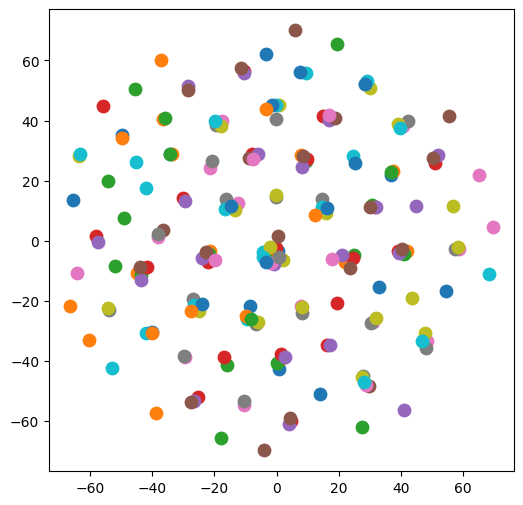

200


In [37]:
plt.figure(figsize=(6,6))
j = 0
for i in range(0, len(embed_2d)-92, 84):
    plt.scatter(embed_2d[i, 0], embed_2d[i, 1], s=80)
    j += 1
plt.savefig('./pictures/fig7_problem_embedding.eps', dpi=300)  # eps文件，用于LaTeX
plt.show()
print(j)

#### 可视化，经过LightGCN得到的skill嵌入, 该数据集上有102个skill

In [38]:
W_S, W_S.shape

(tensor([[-0.5343, -0.0357, -0.5403,  ...,  0.6527, -0.6588,  0.6284],
         [-0.2434,  0.3024, -0.2255,  ..., -0.8251, -0.0073, -1.0231],
         [ 1.3250,  0.4585,  1.0014,  ...,  0.9732, -1.0103, -0.5417],
         ...,
         [-0.9410,  0.5001, -1.2043,  ..., -0.5289,  1.5230, -1.5532],
         [ 0.7284, -0.3884, -0.8891,  ..., -0.6181,  0.0621,  0.4761],
         [-0.5306,  0.3550,  1.7603,  ...,  0.1746, -0.7076, -0.2347]],
        device='cuda:0'),
 torch.Size([102, 128]))

In [39]:
W_S = W_S.cpu().numpy()
W_S, W_S.shape

(array([[-0.5343358 , -0.03573864, -0.5402951 , ...,  0.6526873 ,
         -0.65875983,  0.62841576],
        [-0.24342003,  0.30236608, -0.22545981, ..., -0.825077  ,
         -0.00732435, -1.0231123 ],
        [ 1.3250425 ,  0.4585149 ,  1.001383  , ...,  0.97316885,
         -1.0102743 , -0.54165184],
        ...,
        [-0.94103265,  0.50007236, -1.2042624 , ..., -0.5289487 ,
          1.5230021 , -1.5532365 ],
        [ 0.72841394, -0.38843474, -0.88906914, ..., -0.61807466,
          0.06210471,  0.47609136],
        [-0.53063947,  0.3549515 ,  1.7603414 , ...,  0.17455497,
         -0.70759326, -0.23472278]], dtype=float32),
 (102, 128))

In [40]:
# 将Embedding用TSNE降维到2维
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, n_iter=1000)
embed_2d = tsne.fit_transform(W_S)

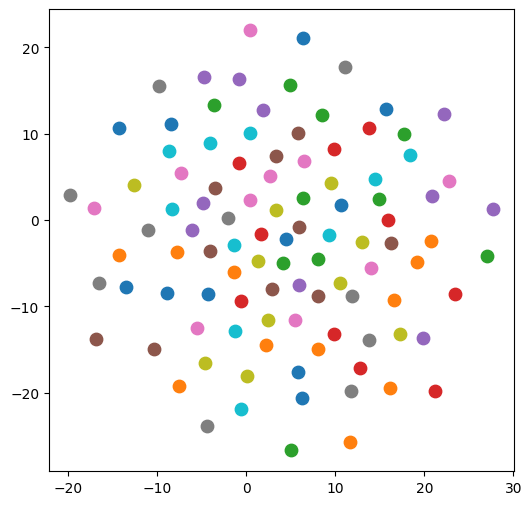

102


In [42]:
plt.figure(figsize=(6,6))
j = 0
for i in range(0, len(embed_2d)):
    plt.scatter(embed_2d[i, 0], embed_2d[i, 1], s=80)
    j += 1
plt.savefig('./pictures/fig7_skill_embedding_s80.eps', dpi=300)  # eps文件，用于LaTeX
plt.show()
print(j)